# Previsão de Entregas: SLE & Monte Carlo

[Repositório no GitHub](https://github.com/rodbv/quando-vai-ficar-pronto)  |  [Slides da palestra](https://rodbv.github.io/quando-vai-ficar-pronto/)

Este notebook é um companion dos slides da talk **Quando vai ficar pronto?**. Aqui você pode simular previsões de entrega usando seus próprios dados.

---

## Como usar com seus dados

1. **Troque o CSV:**
   - O notebook já usa por padrão um arquivo realista: `dados.csv` (cópia de dados limpos de 2026).
   - Para usar outro arquivo, faça upload pelo Jupyter e troque o nome na célula destacada.
   - O CSV deve ter pelo menos as colunas: `started_at` e `finished_at` (datas ou datetimes; a hora é ignorada).
   - Colunas extras são ignoradas.

2. **Ajuste os parâmetros:**
   - Nas células destacadas com **TROQUE AQUI**, altere o número de itens (cards) ou dias para simular diferentes cenários.

---

## Importações e setup


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Lê o CSV atualizado
csv_path = './notebook/lead_time_data_clean_2026.csv'
df = pd.read_csv(csv_path, header=None, names=["started_at", "finished_at", "_"], usecols=[0, 1])

df["started_at"] = pd.to_datetime(df["started_at"])
df["finished_at"] = pd.to_datetime(df["finished_at"])

# Calcula o lead time em dias
lead_time = (df["finished_at"] - df["started_at"]).dt.days + 1
finished_dates = df["finished_at"].dt.normalize()

# Percentis
p50 = np.percentile(lead_time, 50)
p85 = np.percentile(lead_time, 85)

plt.figure(figsize=(12, 5))
plt.scatter(finished_dates, lead_time, color="#27ae60", alpha=0.6)
plt.axhline(p50, color="#00b050", linestyle="--", lw=2, label=f"P50: {int(p50)} dias")
plt.axhline(p85, color="#0050b0", linestyle="--", lw=2, label=f"P85: {int(p85)} dias")
plt.xlabel("Data de entrega")
plt.ylabel("Lead time (dias)")
plt.title("Lead Time Scatterplot (dados reais de 2026)")
plt.legend()
plt.tight_layout()
plt.show()

# Previsão de Entregas: SLE & Monte Carlo

[Repositório no GitHub](https://github.com/rodbv/quando-vai-ficar-pronto)  |  [Slides da palestra](https://rodbv.github.io/quando-vai-ficar-pronto/)

Este notebook é um companion dos slides da talk **Quando vai ficar pronto?**. Aqui você pode simular previsões de entrega usando seus próprios dados.


# Previsão: SLE (1 item) e Monte Carlo (N itens)

Notebook *companion* dos slides da talk **"Quando vai ficar pronto?"**.

Ideia central (igual slides): previsão = **dados históricos** + **probabilidade**.

O que você consegue aqui:
- **SLE (Service Level Expectation)**: em quantos dias terminamos **1 item** com X% de confiança.
- **Simulação Monte Carlo**: em quantos dias terminamos **N itens** com X% de confiança.

Regras (decisões deste notebook):
- Input mínimo: CSV com `started_at` e `finished_at`.
- Se vier datetime, **ignora hora** (normaliza para data).
- Throughput **sempre por dia** (inclui fins de semana + zeros no intervalo).

In [13]:
import sys
from pathlib import Path

# Garante import do helper `notebook/flow_forecast.py` independente do cwd.
repo_root = Path.cwd()
helper_dir = repo_root / "notebook"
if helper_dir.exists():
    sys.path.insert(0, str(helper_dir))
else:
    sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from flow_forecast import (
    cycle_time_days_values,
    daily_throughput,
    monte_carlo_days_to_finish,
    monte_carlo_items_in_days,
    percentiles_from_sim,
    read_items_csv,
    sle_days,
)


## Dados de entrada

Nos slides, a premissa é: você só precisa coletar duas coisas por item:
- data de início (`started_at`)
- data de fim (`finished_at`)

A partir disso, derivamos:
- **Lead time / cycle time (em dias)** de cada item
- **Throughput diário** (quantos itens terminaram por dia)


---

## Como usar com seus dados

1. **Troque o CSV:**
   - Substitua o arquivo `exemplo.csv` pelo seu próprio CSV, ou edite o caminho na célula destacada abaixo.
   - O CSV deve ter pelo menos as colunas: `started_at` e `finished_at` (datas ou datetimes; a hora é ignorada).
   - Para subir um arquivo pelo Jupyter, use o menu `Upload` na interface do notebook.

2. **Ajuste os parâmetros:**
   - Nas células destacadas com **TROQUE AQUI**, altere o número de itens (cards) ou dias para simular diferentes cenários.


In [ ]:
# TROQUE AQUI: Caminho do CSV com seus dados
CSV_PATH = Path("notebook/lead_time_data_clean_2026.csv")  # Exemplo realista, dados limpos de 2026

# TROQUE AQUI: Nível de confiança (ex.: 0.85 = 85%)
CONFIDENCE = 0.85

# TROQUE AQUI: Parâmetros da simulação Monte Carlo
N_ITEMS = 50   # Número de cards para simular entrega
N_DAYS = 30    # Número de dias para simular quantos itens cabem
RUNS = 10_000  # Número de simulações
SEED = 42

In [15]:
df = read_items_csv(CSV_PATH)
df.head()

,started_at,finished_at
0,2026-04-09,2026-04-09
1,2026-04-08,2026-04-09
2,2026-04-06,2026-04-08
3,2026-04-08,2026-04-08
4,2026-04-06,2026-04-07


In [16]:
print(f"rows={len(df)}")
print(f"started_at:  {df['started_at'].min().date()} → {df['started_at'].max().date()}")
print(f"finished_at: {df['finished_at'].min().date()} → {df['finished_at'].max().date()}")

rows=20
started_at:  2026-03-09 → 2026-04-09
finished_at: 2026-03-31 → 2026-04-09


## Previsão de 1 item: percentis e SLE

Nos slides, a ideia é que nosso trabalho tem **cauda longa**: é mais fácil aparecer algo que atrase do que algo que adiante.

Então, em vez de média, usamos **percentis** do lead time histórico.

- Ex.: **P85 = 11 dias** significa: *85% dos itens terminam em 11 dias ou menos*.
- O **SLE** é esse compromisso probabilístico: *"nosso SLE atual é X dias @ Y%"*.

In [17]:
# (Removida: célula redundante de exibição de resultados SLE)

In [18]:
from IPython.display import display, Markdown

# Calcula percentis SLE (1 item)
ct = cycle_time_days_values(df)
pcts = {
    50: int(np.percentile(ct, 50)),
    85: int(np.percentile(ct, 85)),
    95: int(np.percentile(ct, 95)),
}
sle = sle_days(ct, confidence=CONFIDENCE)

# Exibe apenas os resultados do SLE (1 item)
display(Markdown(f'''
<div style="background:#e0f0ff; border:2px solid #0050b0; padding:16px; font-size:1.2em">
<b>Resultado SLE (1 item):</b><br><br>
<ul>
<li><b>P50:</b> {pcts[50]} dias</li>
<li><b>P85:</b> {pcts[85]} dias</li>
<li><b>P95:</b> {pcts[95]} dias</li>
<li><b>SLE:</b> {sle} dias @ {int(CONFIDENCE*100)}%</li>
</ul>
<em>Veja acima os valores simulados para o seu cenário.</em>
</div>
'''))


<div style="background:#e0f0ff; border:2px solid #0050b0; padding:16px; font-size:1.2em">
<b>Resultado SLE (1 item):</b><br><br>
<ul>
<li><b>P50:</b> 4 dias</li>
<li><b>P85:</b> 10 dias</li>
<li><b>P95:</b> 16 dias</li>
<li><b>SLE:</b> 11 dias @ 85%</li>
</ul>
<em>Veja acima os valores simulados para o seu cenário.</em>
</div>


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calcula os valores de lead time e datas de entrega
ct = cycle_time_days_values(df)
finished_dates = pd.to_datetime(df['finished_at']).dt.normalize()

# Percentis
p50 = np.percentile(ct, 50)
p85 = np.percentile(ct, 85)

plt.figure(figsize=(12, 5))
plt.scatter(finished_dates, ct, color="#27ae60", alpha=0.6)

# Linhas horizontais para os percentis
plt.axhline(p50, color="#00b050", linestyle="--", lw=2, label=f"P50: {int(p50)} dias")
plt.axhline(p85, color="#0050b0", linestyle="--", lw=2, label=f"P85: {int(p85)} dias")

plt.xlabel("Data de entrega")
plt.ylabel("Lead time (dias)")
plt.title("Lead Time Scatterplot (dados reais de 2026)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calcula os valores de lead time e datas de entrega
ct = cycle_time_days_values(df)
finished_dates = pd.to_datetime(df['finished_at']).dt.normalize()

# Percentis
p50 = np.percentile(ct, 50)
p85 = np.percentile(ct, 85)

plt.figure(figsize=(12, 5))
plt.scatter(finished_dates, ct, color="#27ae60", alpha=0.6)

# Linhas horizontais para os percentis
plt.axhline(p50, color="#00b050", linestyle="--", lw=2, label=f"P50: {int(p50)} dias")
plt.axhline(p85, color="#0050b0", linestyle="--", lw=2, label=f"P85: {int(p85)} dias")

plt.xlabel("Data de entrega")
plt.ylabel("Lead time (dias)")
plt.title("Lead Time Scatterplot (dados reais de 2026)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

plt.figure(figsize=(10, 2))
plt.scatter(ct, np.ones_like(ct), color="#0050b0", s=80, alpha=0.8)

# Linhas de percentis com legenda manual para garantir estilo
p_colors = {50: "#00b050", 85: "#ff9900", 95: "#d62728"}
p_styles = {50: (0, (6, 3)), 85: (0, (6, 3)), 95: (0, (6, 3))}
legend_lines = []
for p in [50, 85, 95]:
    perc = np.percentile(ct, p)
    line = plt.axvline(perc, color=p_colors[p], linestyle="--", lw=2)
    legend_lines.append(mlines.Line2D([], [], color=p_colors[p], linestyle="--", lw=2, label=f"P{p}"))

plt.yticks([])
plt.xlabel("Dias para concluir um item")
plt.title("Distribuição dos Cycle Times (SLE)")
plt.legend(handles=legend_lines)
plt.tight_layout()
plt.show()

## Previsão de N itens: throughput diário

Para vários itens, a base deixa de ser o lead time individual e passa a ser o **throughput**.

Aqui, throughput é **quantos itens terminaram por dia**. Incluímos explicitamente dias com 0 entregas (inclusive fins de semana).

In [19]:
tp = daily_throughput(df)
print(f"dias no histórico={len(tp)}")
print(f"média={tp.mean():.2f} itens/dia")
print(f"min={tp.min()}  max={tp.max()}")
print(f"% dias zero={float((tp==0).mean()*100):.1f}%")

dias no histórico=10
média=2.00 itens/dia
min=0  max=6
% dias zero=40.0%


## Simulação Monte Carlo: quando entregamos N itens?

O que a simulação faz (igual slides):

- Você tem um histórico de throughput diário: `[1, 0, 1, 3, 2, 0, ...]`
- Para simular a entrega de `N_ITEMS`, você vai **sorteando** um valor por dia desse histórico e acumulando até concluir.
- Repete isso `RUNS` vezes e olha percentis (P50, P85, P95) dos resultados.

In [20]:
sim = monte_carlo_days_to_finish(N_ITEMS, tp, runs=RUNS, seed=SEED)
out = percentiles_from_sim(sim, ps=(50, 85, 95))

print(f"runs={RUNS}  n_items={N_ITEMS}")
print(f"P50={out[50]:.0f} dias  P85={out[85]:.0f} dias  P95={out[95]:.0f} dias")

runs=10000  n_items=50
P50=25 dias  P85=32 dias  P95=36 dias


In [21]:
from IPython.display import display, Markdown

display(Markdown(f'''
<div style="background:#e0ffe0; border:2px solid #008000; padding:16px; font-size:1.2em">
<b>Resultado Monte Carlo (N dias):</b><br><br>
<ul>
<li><b>P50:</b> {out[50]:.0f} itens</li>
<li><b>P85:</b> {out[85]:.0f} itens</li>
<li><b>P95:</b> {out[95]:.0f} itens</li>
</ul>
<em>Veja acima os valores simulados para o seu cenário.</em>
</div>
'''))


<div style="background:#e0ffe0; border:2px solid #008000; padding:16px; font-size:1.2em">
<b>Resultado Monte Carlo (N dias):</b><br><br>
<ul>
<li><b>P50:</b> 25 itens</li>
<li><b>P85:</b> 32 itens</li>
<li><b>P95:</b> 36 itens</li>
</ul>
<em>Veja acima os valores simulados para o seu cenário.</em>
</div>


### Interpretando resultado

- **P85** costuma ser bom default para comunicar externamente: erro ~15% por definição.
- P50 erra metade das vezes.
- P95 é mais conservador.


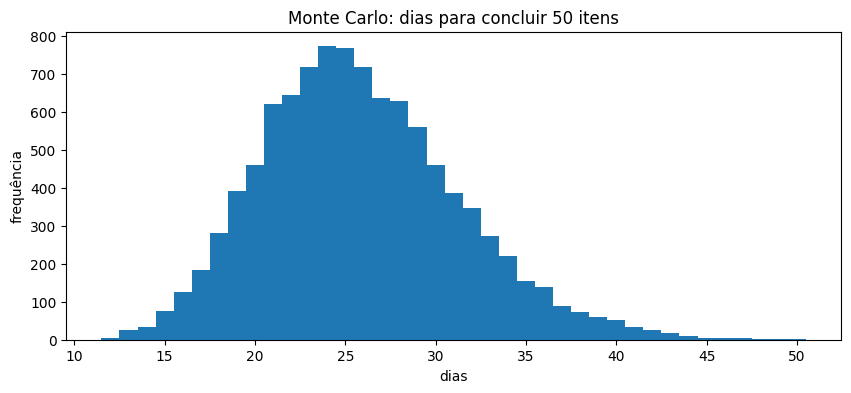

In [22]:
plt.figure(figsize=(10, 4))
bins = range(int(sim.min()), int(sim.max()) + 2)
plt.hist(sim, bins=bins, align="left")
plt.title(f"Monte Carlo: dias para concluir {N_ITEMS} itens")
plt.xlabel("dias")
plt.ylabel("frequência")
plt.show()

## Simulação Monte Carlo: quantos itens cabem em N dias?

Outra pergunta comum (também aparece nos slides):

- Dado um prazo fixo de `N_DAYS`, **quantos itens** conseguimos entregar?

A mecânica é igual: em cada simulação, sorteamos `N_DAYS` valores de throughput do histórico e somamos.

In [23]:
sim_items = monte_carlo_items_in_days(N_DAYS, tp, runs=RUNS, seed=SEED)
out_items = percentiles_from_sim(sim_items, ps=(50, 85, 95))

print(f"runs={RUNS}  n_days={N_DAYS}")
print(f"P50={out_items[50]:.0f} itens  P85={out_items[85]:.0f} itens  P95={out_items[95]:.0f} itens")

runs=10000  n_days=30
P50=60 itens  P85=72 itens  P95=80 itens


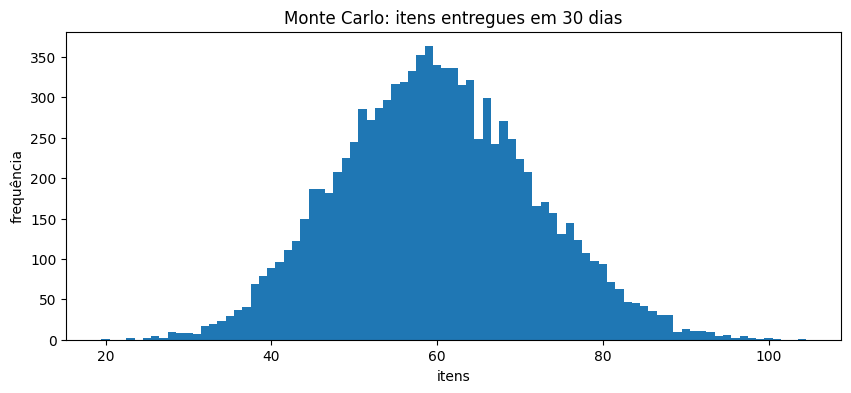

In [24]:
plt.figure(figsize=(10, 4))
bins = range(int(sim_items.min()), int(sim_items.max()) + 2)
plt.hist(sim_items, bins=bins, align="left")
plt.title(f"Monte Carlo: itens entregues em {N_DAYS} dias")
plt.xlabel("itens")
plt.ylabel("frequência")
plt.show()